# **업무 이메일 자동화 AI 파이프라인**
---

## Ⅰ. 환경 설정 및 데이터 로드

1. 패키지 설치 + Drive Mount

In [1]:
!pip install sentence-transformers scikit-learn pandas numpy seaborn matplotlib

# 한글 폰트 설치 (Colab 세션 시작마다 실행 필요)
!apt-get update -qq
!apt-get install -y fonts-nanum -qq
!fc-cache -fv

from google.colab import drive
drive.mount('/content/drive')

W: Skipping acquire of configured file 'main/source/Sources' as repository 'https://r2u.stat.illinois.edu/ubuntu jammy InRelease' does not seem to provide it (sources.list entry misspelt?)
/usr/share/fonts: caching, new cache contents: 0 fonts, 1 dirs
/usr/share/fonts/truetype: caching, new cache contents: 0 fonts, 3 dirs
/usr/share/fonts/truetype/humor-sans: caching, new cache contents: 1 fonts, 0 dirs
/usr/share/fonts/truetype/liberation: caching, new cache contents: 16 fonts, 0 dirs
/usr/share/fonts/truetype/nanum: caching, new cache contents: 12 fonts, 0 dirs
/usr/local/share/fonts: caching, new cache contents: 0 fonts, 0 dirs
/root/.local/share/fonts: skipping, no such directory
/root/.fonts: skipping, no such directory
/usr/share/fonts/truetype: skipping, looped directory detected
/usr/share/fonts/truetype/humor-sans: skipping, looped directory detected
/usr/share/fonts/truetype/liberation: skipping, looped directory detected
/usr/share/fonts/truetype/nanum: skipping, looped dire

2.  sys.path 등록 + 폴더 구조 확인

In [2]:
import os, sys

SRC_DIR = "/content/drive/MyDrive/Capstone_AI2/src"

if SRC_DIR not in sys.path:
    sys.path.insert(0, SRC_DIR)

from config import (
    BASE_DIR, DATA_DIR, MODEL_DIR, SRC_DIR,
    OUTPUT_DIR, FIGURES_DIR, REPORTS_DIR, LOG_DIR,
    DATASET_PATH, PAIRS_CSV_PATH,
    EMBEDDINGS_BASELINE_PATH, EMBEDDINGS_FINETUNED_PATH,
    SBERT_MODEL_PATH,
    DOMAIN_CLF_PATH, DOMAIN_LE_PATH,
    INTENT_CLF_PATH, INTENT_LE_PATH,
)

print("=" * 55)
print("폴더 구조 확인")
print("=" * 55)
folders = {
    "data/"           : DATA_DIR,
    "models/"         : MODEL_DIR,
    "src/"            : SRC_DIR,
    "outputs/figures/": FIGURES_DIR,
    "outputs/reports/": REPORTS_DIR,
    "outputs/logs/"   : LOG_DIR,
}
for name, path in folders.items():
    status = "✔" if os.path.exists(path) else "❌"
    print(f"  {status}  {name:<22} {path}")

print("\n" + "=" * 55)
print("src 파일 확인")
print("=" * 55)
for fname in ["config.py", "data_utils.py", "train_sbert.py",
              "train_domain.py", "train_intent.py",
              "evaluation.py", "inference.py"]:
    path   = os.path.join(SRC_DIR, fname)
    status = "✔" if os.path.exists(path) else "❌ 없음"
    print(f"  {status}  {fname}")

폴더 구조 확인
  ✔  data/                  /content/drive/MyDrive/Capstone_AI2/data
  ✔  models/                /content/drive/MyDrive/Capstone_AI2/models
  ✔  src/                   /content/drive/MyDrive/Capstone_AI2/src
  ✔  outputs/figures/       /content/drive/MyDrive/Capstone_AI2/outputs/figures
  ✔  outputs/reports/       /content/drive/MyDrive/Capstone_AI2/outputs/reports
  ✔  outputs/logs/          /content/drive/MyDrive/Capstone_AI2/outputs/logs

src 파일 확인
  ✔  config.py
  ✔  data_utils.py
  ✔  train_sbert.py
  ✔  train_domain.py
  ✔  train_intent.py
  ✔  evaluation.py
  ✔  inference.py


3. 데이터 로드 및 검증

In [3]:
from data_utils import load_dataset

df = load_dataset()

print(f"\n[도메인별 샘플 수]")
print(df.groupby("domain")["intent"].count().to_string())
print(f"\n[도메인 × 인텐트 분포]")
print(df.groupby(["domain", "intent"]).size().reset_index(name="count").to_string(index=False))

[load_dataset] 총 샘플: 1200 | 도메인: 7 | 인텐트: 30

[도메인별 샘플 수]
domain
Admin               160
Customer Support    160
Finance             160
HR                  160
IT/Ops              120
Marketing & PR      240
Sales               200

[도메인 × 인텐트 분포]
          domain    intent  count
           Admin        공지     40
           Admin     내부 보고     40
           Admin     자료 요청     40
           Admin     협조 요청     40
Customer Support  기술 지원 요청     40
Customer Support     불만 접수     40
Customer Support    사용법 문의     40
Customer Support     환불 요청     40
         Finance  비용 처리 문의     40
         Finance  세금계산서 요청     40
         Finance  입금 확인 요청     40
         Finance     정산 문의     40
              HR     면접 조율     40
              HR 증명서 발급 요청     40
              HR     채용 문의     40
              HR     휴가 신청     40
          IT/Ops  계정 생성 요청     40
          IT/Ops  권한 변경 요청     40
          IT/Ops 시스템 오류 보고     40
  Marketing & PR     광고 문의     40
  Marketing & PR   보도자료 요청     40
  M

## Ⅱ. SBERT 파인튜닝 및 임베딩 생성

**1. SBERT Fine-tuning**

In [4]:
from train_sbert import run_sbert_finetuning

model = run_sbert_finetuning()

[load_pairs_csv] 복원 완료: 4500개
[split_pairs] Train: 4050 | Val: 450


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

BertModel LOAD REPORT from: sentence-transformers/paraphrase-multilingual-MiniLM-L12-v2
Key                     | Status     |  | 
------------------------+------------+--+-
embeddings.position_ids | UNEXPECTED |  | 

Notes:
- UNEXPECTED	:can be ignored when loading from different task/architecture; not ok if you expect identical arch.


[run_sbert_finetuning] 배치: 254 | warmup: 127
저장 경로: /content/drive/MyDrive/Capstone_AI2/models/sbert_business_email



...

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

Writing model shards:   0%|          | 0/1 [00:00<?, ?it/s]

[run_sbert_finetuning] 완료 → /content/drive/MyDrive/Capstone_AI2/models/sbert_business_email


Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

**2. 임베딩 생성 + data/ 저장**

In [5]:
from train_sbert import generate_embeddings
from config import EMBEDDINGS_FINETUNED_PATH

X = generate_embeddings(
    texts    =df["email_text"].tolist(),
    save_path=EMBEDDINGS_FINETUNED_PATH,
)

print(f"\n임베딩 저장 경로 : {EMBEDDINGS_FINETUNED_PATH}")
print(f"임베딩 shape     : {X.shape}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

Batches:   0%|          | 0/19 [00:00<?, ?it/s]

[generate_embeddings] shape: (1200, 384)
[save_embeddings] 저장 완료 → /content/drive/MyDrive/Capstone_AI2/data/embeddings_finetuned.npy

임베딩 저장 경로 : /content/drive/MyDrive/Capstone_AI2/data/embeddings_finetuned.npy
임베딩 shape     : (1200, 384)


**3.  임베딩 품질 검증**

In [6]:
from evaluation import validate_embeddings

validate_embeddings(X, df)

SBERT 임베딩 품질 검증
  Shape : (1200, 384) | Mean: 0.0002 | Std: 0.0510

[Cosine Similarity 샘플 검증]
  같은 Intent : 0.7975  ← 높을수록 좋음
  다른 Intent : 0.2046  ← 낮을수록 좋음
  랜덤 (0,100): 0.2595

[도메인별 Intra-class 평균 Cosine Similarity]
  Admin                    : 0.8617
  Customer Support         : 0.8366
  Finance                  : 0.7207
  HR                       : 0.9627
  IT/Ops                   : 0.9747
  Marketing & PR           : 0.9179
  Sales                    : 0.7923


## Ⅲ. 분류기 학습 및 평가

**1. Domain Classifier 학습 + 평가**

/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Domain Classifier] K-Fold 결과
  Weighted F1 : 0.8609 ± 0.0261
  Macro F1    : 0.8554 ± 0.0294


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Domain Classifier] Classification Report
                  precision    recall  f1-score   support

           Admin       0.79      0.87      0.83       160
Customer Support       0.82      0.91      0.86       160
         Finance       0.87      0.72      0.79       160
              HR       0.81      0.86      0.83       160
          IT/Ops       0.96      0.78      0.86       120
  Marketing & PR       0.91      0.93      0.92       240
           Sales       0.89      0.89      0.89       200

        accuracy                           0.86      1200
       macro avg       0.86      0.85      0.86      1200
    weighted avg       0.87      0.86      0.86      1200



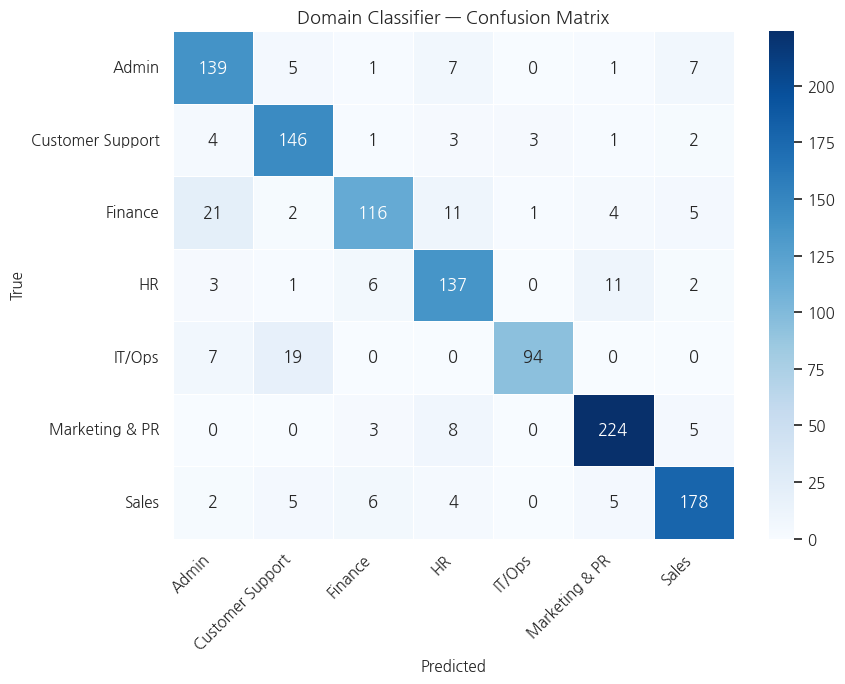

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/domain_confusion_matrix.png


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


[train_domain] 저장 완료 → /content/drive/MyDrive/Capstone_AI2/models


In [7]:
from train_domain import train_domain_classifier

domain_clf, le_domain = train_domain_classifier(X, df["domain"].values)

**2.  Intent Classifier 학습 + 평가**

Intent Classifier — 도메인별 학습 및 평가

[Admin] 샘플: 160 | 인텐트: 4 | K=5

[Intent [Admin]] K-Fold 결과
  Weighted F1 : 1.0000 ± 0.0000
  Macro F1    : 1.0000 ± 0.0000

[Intent [Admin]] Classification Report


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

              precision    recall  f1-score   support

          공지       1.00      1.00      1.00        40
       내부 보고       1.00      1.00      1.00        40
       자료 요청       1.00      1.00      1.00        40
       협조 요청       1.00      1.00      1.00        40

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



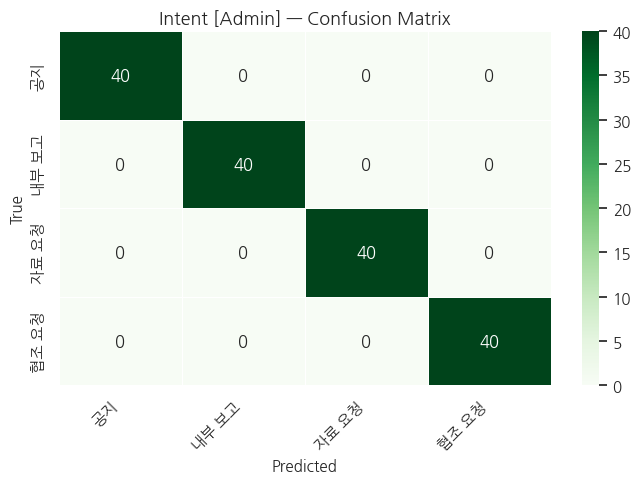

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_Admin.png

[Customer Support] 샘플: 160 | 인텐트: 4 | K=5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Intent [Customer Support]] K-Fold 결과
  Weighted F1 : 0.9875 ± 0.0154
  Macro F1    : 0.9875 ± 0.0154


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(



[Intent [Customer Support]] Classification Report
              precision    recall  f1-score   support

    기술 지원 요청       0.97      0.97      0.97        40
       불만 접수       0.98      1.00      0.99        40
      사용법 문의       1.00      0.97      0.99        40
       환불 요청       1.00      1.00      1.00        40

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



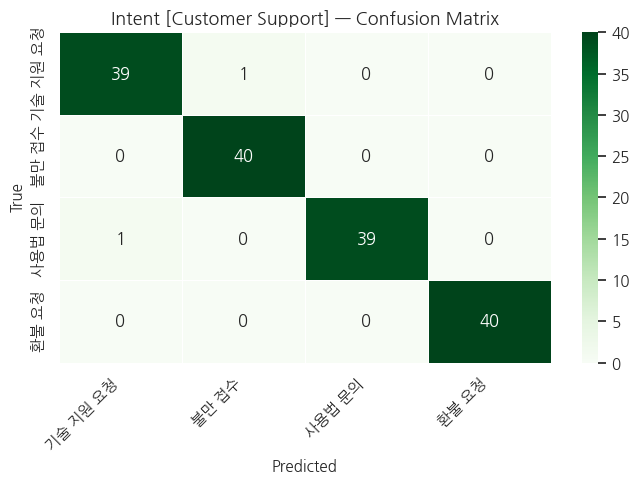

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_Customer_Support.png

[Finance] 샘플: 160 | 인텐트: 4 | K=5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Intent [Finance]] K-Fold 결과
  Weighted F1 : 0.9937 ± 0.0125
  Macro F1    : 0.9937 ± 0.0125

[Intent [Finance]] Classification Report
              precision    recall  f1-score   support

    비용 처리 문의       0.98      1.00      0.99        40
    세금계산서 요청       1.00      1.00      1.00        40
    입금 확인 요청       1.00      1.00      1.00        40
       정산 문의       1.00      0.97      0.99        40

    accuracy                           0.99       160
   macro avg       0.99      0.99      0.99       160
weighted avg       0.99      0.99      0.99       160



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


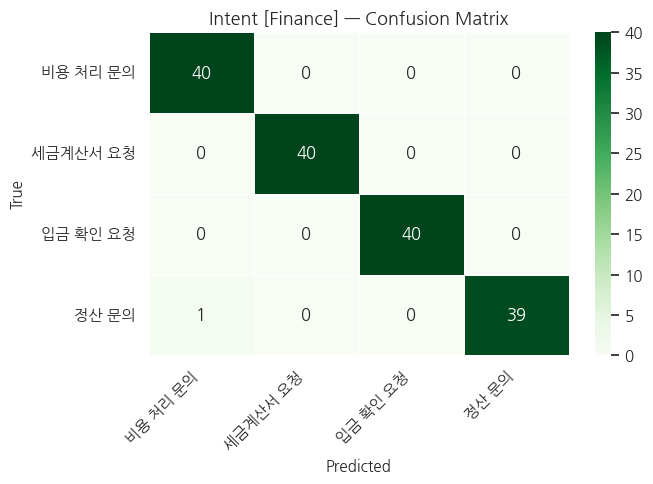

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_Finance.png

[HR] 샘플: 160 | 인텐트: 4 | K=5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Intent [HR]] K-Fold 결과
  Weighted F1 : 1.0000 ± 0.0000
  Macro F1    : 1.0000 ± 0.0000

[Intent [HR]] Classification Report
              precision    recall  f1-score   support

       면접 조율       1.00      1.00      1.00        40
   증명서 발급 요청       1.00      1.00      1.00        40
       채용 문의       1.00      1.00      1.00        40
       휴가 신청       1.00      1.00      1.00        40

    accuracy                           1.00       160
   macro avg       1.00      1.00      1.00       160
weighted avg       1.00      1.00      1.00       160



/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

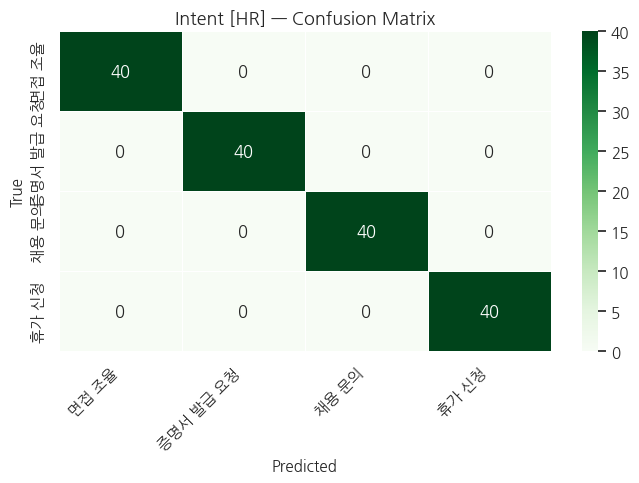

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_HR.png

[IT/Ops] 샘플: 120 | 인텐트: 3 | K=5


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Intent [IT/Ops]] K-Fold 결과
  Weighted F1 : 1.0000 ± 0.0000
  Macro F1    : 1.0000 ± 0.0000

[Intent [IT/Ops]] Classification Report
              precision    recall  f1-score   support

    계정 생성 요청       1.00      1.00      1.00        40
    권한 변경 요청       1.00      1.00      1.00        40
   시스템 오류 보고       1.00      1.00      1.00        40

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120



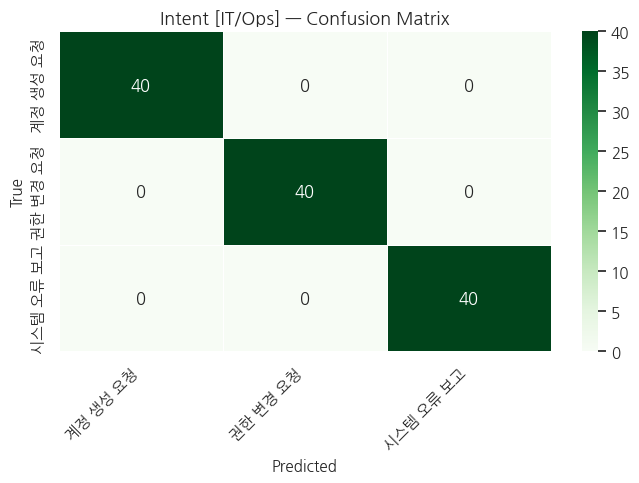

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_IT_Ops.png

[Marketing & PR] 샘플: 240 | 인텐트: 6 | K=5

[Intent [Marketing & PR]] K-Fold 결과
  Weighted F1 : 0.9916 ± 0.0102
  Macro F1    : 0.9916 ± 0.0102


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi


[Intent [Marketing & PR]] Classification Report
              precision    recall  f1-score   support

       광고 문의       1.00      0.97      0.99        40
     보도자료 요청       1.00      1.00      1.00        40
      인터뷰 요청       1.00      1.00      1.00        40
   콘텐츠 협업 문의       1.00      0.97      0.99        40
   행사/캠페인 문의       0.98      1.00      0.99        40
    협찬/제휴 제안       0.98      1.00      0.99        40

    accuracy                           0.99       240
   macro avg       0.99      0.99      0.99       240
weighted avg       0.99      0.99      0.99       240



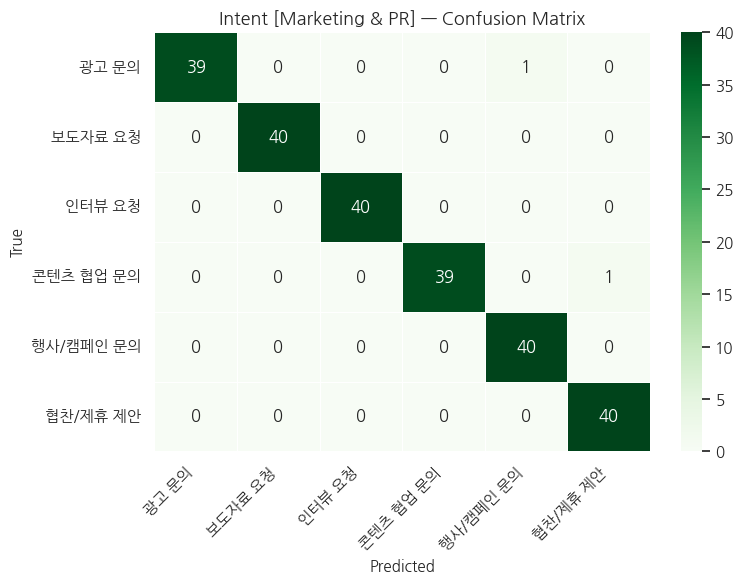

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_Marketing_&_PR.png

[Sales] 샘플: 200 | 인텐트: 5 | K=5

[Intent [Sales]] K-Fold 결과
  Weighted F1 : 1.0000 ± 0.0000
  Macro F1    : 1.0000 ± 0.0000

[Intent [Sales]] Classification Report


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and wi

              precision    recall  f1-score   support

       가격 협상       1.00      1.00      1.00        40
       견적 요청       1.00      1.00      1.00        40
       계약 문의       1.00      1.00      1.00        40
    미팅 일정 조율       1.00      1.00      1.00        40
       제안 요청       1.00      1.00      1.00        40

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



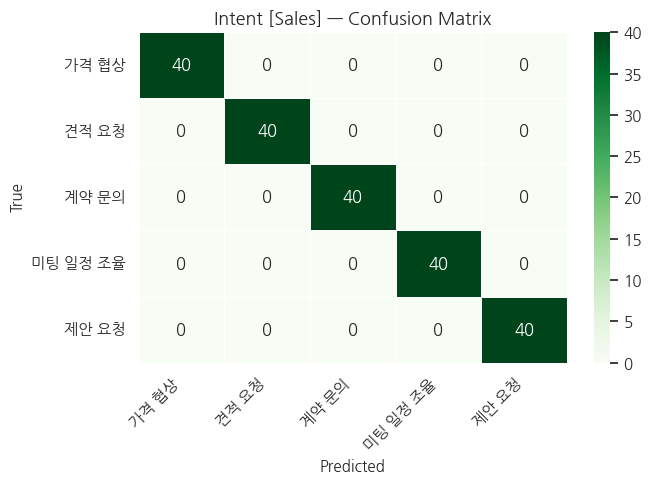

Confusion Matrix 저장 → /content/drive/MyDrive/Capstone_AI2/outputs/figures/intent_cm_Sales.png

[train_intent] 저장 완료 → /content/drive/MyDrive/Capstone_AI2/models


/usr/local/lib/python3.12/dist-packages/sklearn/linear_model/_logistic.py:1247: FutureWarning: 'multi_class' was deprecated in version 1.5 and will be removed in 1.7. From then on, it will always use 'multinomial'. Leave it to its default value to avoid this warning.
  warnings.warn(


In [8]:
from train_intent import train_intent_classifiers

intent_classifiers, intent_encoders = train_intent_classifiers(X, df)

## Ⅳ. 추론 파이프라인 테스트

1. 추론 파이프라인 로드 + 테스트

In [9]:
from inference import load_pipeline, predict_email

pipeline = load_pipeline()

test_emails = [
    "안녕하세요. 귀사의 서비스에 대한 견적서를 요청드립니다.",
    "채용 관련 문의드립니다. 개발자 포지션 지원이 가능한지 확인하고 싶습니다.",
    "시스템 오류가 발생했습니다. 로그인이 되지 않아 긴급 지원 요청드립니다.",
]

print("=" * 55)
print("추론 테스트")
print("=" * 55)
for email in test_emails:
    result = predict_email(email, pipeline)
    print(f"\n입력   : {email[:45]}...")
    print(f"  Domain : {result['domain']:<20} (confidence: {result['domain_confidence']})")
    print(f"  Intent : {result['intent']:<20} (confidence: {result['intent_confidence']})")
    print(f"  Low confidence 플래그 : {result['low_confidence']}")

Loading weights:   0%|          | 0/199 [00:00<?, ?it/s]

[load_pipeline] ✅ 파이프라인 로드 완료
추론 테스트

입력   : 안녕하세요. 귀사의 서비스에 대한 견적서를 요청드립니다....
  Domain : HR                   (confidence: 0.4814)
  Intent : 증명서 발급 요청            (confidence: 0.9121)
  Low confidence 플래그 : True

입력   : 채용 관련 문의드립니다. 개발자 포지션 지원이 가능한지 확인하고 싶습니다....
  Domain : Marketing & PR       (confidence: 0.4974)
  Intent : 행사/캠페인 문의            (confidence: 0.4524)
  Low confidence 플래그 : True

입력   : 시스템 오류가 발생했습니다. 로그인이 되지 않아 긴급 지원 요청드립니다....
  Domain : Customer Support     (confidence: 0.699)
  Intent : 기술 지원 요청             (confidence: 0.774)
  Low confidence 플래그 : False
